# Points across minutes-bands — characterising the 60-minute mark *(population)*

*Read-only informative artifact. Sits in the **Descriptive** tier: it describes
how the target Y (`total_points`) sits across the minutes axis — the bands × Y
relational read — so a human can see whether the 60-minute mark separates two
scoring regimes. It imposes no gate, runs no PROCEED/STOP verdict, and makes no
causal claim.*

## Questions a manager asks about the 60-minute mark

- **Does the 60-minute mark actually separate two regimes** — a cameo regime
  where points barely move, and a genuine-starter regime where scoring lifts —
  or is it an arbitrary line drawn through one continuous landscape?
- **What would a 60-minute filter include and exclude?** Which appearances does
  it keep as "genuine outings" and which cameos does it discard?
- **Is 60 a sensible boundary or an arbitrary one?** Other foundation layers
  use a `minutes > 0` participation filter and explicitly defer the 60-minute
  question to here — this notebook is where it gets looked at.

Everything below is **season-pooled**. The population is the **wider featured
base** (all rows with `minutes > 0`) examined across the **full minutes axis**
— because the boundary question is about what happens *along* that axis, not
within one slice of it. The minutes bands themselves are established in
`minutes_distribution.ipynb`.

## Setup

Load the mart, restrict to the **whole season** (GW 1 to the latest completed
GW), and take the **wider featured base**: all rows with `minutes > 0`. We then
examine `total_points` and scoring rates **across the full minutes axis**, with
the 60-minute mark drawn in for reference.

The population is the **participation** base (`minutes > 0` — the player
featured). `minutes` can be NULL on blank-gameweek rows; `minutes > 0` excludes
those naturally. We deliberately keep the **whole** featured range — cameos
included — because the entire point of this notebook is to look at the boundary
*in situ*, not to apply it. No 60-minute filter is imposed anywhere below.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from research.kernels.descriptive.distribution import (
    compute_distribution_stats,
    compare_cohorts,
)

try:
    _result = load_mart()
except (MartNotBuiltError, MartSchemaError) as _e:
    print(f"Rebuilding mart ({type(_e).__name__})...")
    run_pipeline(force=True)
    _result = load_mart()

# Descriptive characterisation uses the WHOLE season: GW 1 to the latest
# completed GW. No early-GW lower bound (that was a predictive-evaluation
# choice in the older EDA-1 record, not relevant here).
STUDY_GW_MIN = 1
STUDY_GW_MAX = _result.data_cutoff_gw

POSITIONS = ["GK", "DEF", "MID", "FWD"]
mart = _result.mart

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:.3f}".format)

# WIDER featured base for the boundary question: all rows with minutes > 0,
# examined across the FULL minutes axis. No 60-minute filter is imposed.
# DGW excluded for now (is_dgw == False) so the axis is single-fixture -- no
# ~180-minute doubled rows confounding the binned mean.
df = mart[mart["gw"].between(STUDY_GW_MIN, STUDY_GW_MAX)].copy()
df = df[df["minutes"].notna() & (df["minutes"] > 0)].copy()
df = df[df["is_dgw"] == False].copy()

cohorts = {pos: df[df.position == pos] for pos in POSITIONS}

print(f"Study range: GW {STUDY_GW_MIN} - GW {STUDY_GW_MAX} (whole season, from mart data_cutoff_gw)")
print(f"Population: minutes > 0, DGW excluded (wider featured base, full minutes axis), n = {len(df):,} player-gameweeks")
for pos in POSITIONS:
    print(f"  {pos}: {len(cohorts[pos]):>6,}")

Study range: GW 1 - GW 38 (whole season, from mart data_cutoff_gw)
Population: minutes > 0, DGW excluded (wider featured base, full minutes axis), n = 11,190 player-gameweeks
  GK:    747
  DEF:  3,845
  MID:  5,208
  FWD:  1,390


## (a) `total_points` across the minutes axis

**What we measure** — `total_points` against `minutes` across the full featured
range, as a **binned mean** of points within 5-minute minute-bins (per position
and pooled), with the 60-minute mark drawn in. A binned mean is used in place
of a raw scatter because the minutes axis is heavily discretised (mass piles on
90, 45, sub points) and tens of thousands of overplotted points would hide the
trend; the binned mean exposes whether mean points **lift** at or after 60.

**What it means** — the regime question is a **shape** question, so it is
plotted. If there is a genuine break, mean points stay low and flat through the
cameo range and then step up around 60 as appearances become genuine starts; if
the relationship is a smooth ramp with no kink, 60 is an arbitrary cut through a
continuum. This is the visual evidence for or against "60 separates two
regimes".

**What it doesn't mean** — **this is not a causal claim.** Exposure is
**confounded with player quality**: better players both start (earning more
minutes) and score more, so any lift around 60 reflects *who plays long*, not
the *effect of playing long*. A binned mean is descriptive co-variation, not an
estimate of the return to an extra minute. It is also **season-pooled** with
**DGW excluded** (`is_dgw == False`), so the axis is a single fixture's minutes.
Nothing here is filtered or gated on 60.

**Guiding question (directive)** — *Determine whether mean scoring lifts at or
after the 60-minute mark or ramps smoothly with no break — is 60 a regime
boundary or an arbitrary cut?*

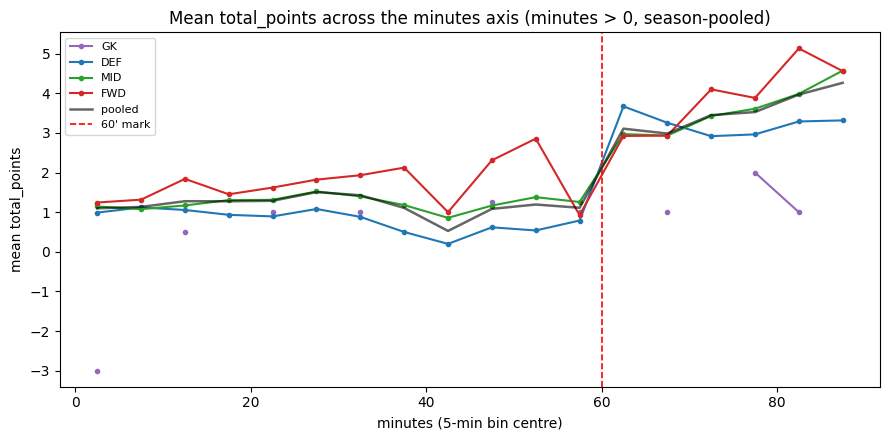

In [2]:
# Binned mean of total_points across 5-minute bins, per position + pooled.
# Binned-mean (not raw scatter) because minutes are heavily discretised and a
# scatter would overplot. DESCRIPTIVE co-variation only -- exposure is
# confounded with player quality (see "What it doesn't mean").
colours = {"GK": "#9467bd", "DEF": "#1f77b4", "MID": "#2ca02c", "FWD": "#d62728"}
edges = np.arange(0, 95, 5)
centres = (edges[:-1] + edges[1:]) / 2

def _binned_mean(frame):
    g = frame.dropna(subset=["minutes", "total_points"]).copy()
    g["bin"] = pd.cut(g["minutes"].astype(float), bins=edges, right=False)
    m = g.groupby("bin", observed=False)["total_points"].mean()
    return m.to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(9, 4.5))
for pos in POSITIONS:
    ax.plot(centres, _binned_mean(cohorts[pos]), "-o", ms=3,
            color=colours[pos], label=pos)
ax.plot(centres, _binned_mean(df), "-", color="black", linewidth=1.8,
        alpha=0.6, label="pooled")
ax.axvline(60, color="red", linestyle="--", linewidth=1.2, label="60' mark")
ax.set_xlabel("minutes (5-min bin centre)")
ax.set_ylabel("mean total_points")
ax.set_title("Mean total_points across the minutes axis (minutes > 0, season-pooled)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## (b) Scoring and blank rate in minutes bands, by position

**What we measure** — within three **minutes bands** (`1-29`, `30-59`, `60+`),
per position, the `total_points` mean and median and the **blank rate**
(`total_points == 0`). One inline table; the count `n` per cell is shown so thin
bands are visible. Bands collapse at `60+` because FPL's rules do not
distinguish `60-89` from `90` (same appearance / clean-sheet regime).

*Stat glossary for this table:* **mean_pts** — average points in the band,
pulled up by rare hauls; **median_pts** — the robust "typical" return;
**blank_rate_%** — share of appearances returning `total_points == 0`.

**What it means** — this is the tabular counterpart to (a): it shows whether
scoring **meaningfully lifts** and blanks **drop** as appearances cross from the
cameo/partial bands into `60+`. A sharp fall in blank rate and a rise in mean
points at `60+` is the signature of a real boundary — the band where
appearances become genuine outings that put up returns. This is exactly the
"what would a 60-minute filter keep" question, made concrete.

**What it doesn't mean** — same confound as (a): the lift across the boundary is
**not causal**. Players who reach 60+ minutes are disproportionately the better,
nailed starters, so the band differences reflect *player composition*, not the
*effect of minutes*. The bands are **season-pooled** with **DGW excluded**. The
`30-59` band in particular mixes genuine half-time substitutions, early-game
injuries, and tactical hooks — a higher blank rate there is partly mechanical (a
player subbed at half-time had less time to score), not a performance verdict.
**No band is excluded or gated.**

**Guiding question (directive)** — *Establish what a 60-minute filter would
include versus discard — quantify how scoring lifts and the blank rate drops
across the mark.*

In [3]:
# Y distribution + blank rate per (position, minutes band). DESCRIPTIVE only;
# the cross-band lift is confounded with player quality and is NOT causal.
# Bands collapse at 60+ (FPL's rules do not distinguish 60-89 from 90); DGW
# already excluded in setup.
BANDS = ["1-29", "30-59", "60+"]

def _band(mn):
    if mn < 30:
        return "1-29"
    if mn < 60:
        return "30-59"
    return "60+"

work = df.dropna(subset=["minutes", "total_points"]).copy()
work["band"] = work["minutes"].astype(int).map(_band)

rows = []
for pos in POSITIONS:
    c = work[work.position == pos]
    for b in BANDS:
        y = c.loc[c["band"] == b, "total_points"].astype(float)
        rows.append({
            "position": pos,
            "band": b,
            "n": len(y),
            "mean_pts": round(y.mean(), 2) if len(y) else np.nan,
            "median_pts": round(y.median(), 1) if len(y) else np.nan,
            "blank_rate_%": round((y == 0).mean() * 100, 1) if len(y) else np.nan,
        })
band_scoring = pd.DataFrame(rows)
band_scoring["band"] = pd.Categorical(band_scoring["band"], categories=BANDS, ordered=True)
band_scoring["position"] = pd.Categorical(band_scoring["position"], categories=POSITIONS, ordered=True)
band_scoring = band_scoring.sort_values(["position", "band"]).reset_index(drop=True)
display(band_scoring)

,position,band,n,mean_pts,median_pts,blank_rate_%
0,GK,1-29,4,-0.250,0.500,25.000
1,GK,30-59,6,1.170,1.000,0.000
2,GK,60+,737,3.380,2.000,2.000
3,DEF,1-29,618,1.020,1.000,8.600
4,DEF,30-59,283,0.640,1.000,27.200
5,DEF,60+,2944,3.690,2.000,6.200
6,MID,1-29,1427,1.250,1.000,5.300
7,MID,30-59,597,1.250,1.000,9.200
8,MID,60+,3184,3.970,3.000,0.300
9,FWD,1-29,504,1.540,1.000,4.000


In [4]:
# Pooled-across-positions view of the same bands: the clearest read of whether
# blanks drop and mean points lift across the 60-minute mark.
rows = []
for b in BANDS:
    y = work.loc[work["band"] == b, "total_points"].astype(float)
    rows.append({
        "band": b,
        "n": len(y),
        "mean_pts": round(y.mean(), 2),
        "median_pts": round(y.median(), 1),
        "blank_rate_%": round((y == 0).mean() * 100, 1),
    })
band_scoring_pooled = pd.DataFrame(rows)
display(band_scoring_pooled)

,band,n,mean_pts,median_pts,blank_rate_%
0,1-29,2553,1.250,1.000,5.900
1,30-59,1030,1.160,1.000,13.400
2,60+,7607,3.820,3.000,2.800


## What the 60-minute boundary looks like

Plain-language summary of the descriptive picture (not a verdict, not a gate,
not a causal claim):

- **There is a clear step at 60, not a smooth ramp.** Pooled mean points sit at
  ~1.2 in the sub-60 bands (`1-29`: 1.25, `30-59`: 1.16) and jump to **3.82** in
  the `60+` band. The binned-mean plot shows the same break visually — flat
  through the cameo range, then a step up around 60.
- **Blanks collapse across the boundary.** The pooled blank rate
  (`total_points == 0`) drops from **13.4%** in the `30-59` band to **2.8%** in
  `60+` — appearances that reach genuine-outing length almost always return
  *something*. This is the concrete content of "what a 60-minute filter keeps
  versus discards".
- **The `30-59` band carries its own mechanical story** — it has the *highest*
  blank rate (13.4%), inflated by half-time hooks and early injuries (a player
  subbed at the break had less time to score), so it should not be read as a
  pure performance verdict.

**Crucial framing.** This notebook **characterises** the 60-minute mark; it does
**not** impose it as a gate, and it makes **no causal claim**. Exposure is
confounded with player quality — better players both start and score — so any
lift across the boundary describes *who plays long*, not the *effect of playing
long*. All figures are **whole-season**, season-pooled, with **DGW excluded**
(`is_dgw == False`); per-fixture DGW treatment is deferred to the `fixture/`
layer.

**Pointer.** Whether the population choice (`minutes > 0` vs `minutes >= 60`)
changes the signal–points association is *described* separately in
`scope_sensitivity.ipynb`; *explaining* any such change is a Diagnostic-tier
analysis, deferred.